In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

import pyrepseq.plotting as pp

plt.style.use('bmh')

In [16]:
df = pd.read_csv('../data/compairr_benchmark_indel.csv', index_col=0)
df = df[df['n_repertoire']>1]
df.head()

,runtime,algorithm,n_sequence,distance,measure,n_repertoire
5,15.368232,symspell,397596,1,leven,2
6,1.005697,xt_neighbor,397596,1,leven,2
7,2.308754,compairr1,397596,1,leven,2
8,0.606652,compairr8,397596,1,leven,2
9,2.711012,symscancli3,397596,1,leven,2


In [17]:
df.groupby(by=["algorithm","n_repertoire","distance","measure"]).agg(['mean','size'])

runtime         n_sequence     
                                                 mean size          mean size
algorithm   n_repertoire distance measure                                    
compairr1   2            1        leven      1.817064   30  3.528237e+05   30
            4            1        leven      4.203821   30  6.762382e+05   30
            8            1        leven      9.562820   30  1.271042e+06   30
            16           1        leven     20.848205   30  2.375209e+06   30
            32           1        leven     48.226793   30  4.431541e+06   30
            64           1        leven    118.154995   30  8.416865e+06   30
compairr8   2            1        leven      0.482079   30  3.528237e+05   30
            4            1        leven      1.004188   30  6.762382e+05   30
            8            1        leven      2.149676   30  1.271042e+06   30
            16           1        leven      4.802948   30  2.375209e+06   30
            32           1        leven     10.817737   30  4.431541e+06   30
            64           1        leven     23.897789   30  8.416865e+06   30
symscancli2 2            1        leven      1.305152   30  3.528237e+05   30
            4            1        leven      2.298440   30  6.762382e+05   30
            8            1        leven      4.236323   30  1.271042e+06   30
            16           1        leven      8.339974   30  2.375209e+06   30
            32           1        leven     16.440970   30  4.431541e+06   30
            64           1        leven     33.269762   30  8.416865e+06   30
symscancli3 2            1        leven      2.372142   30  3.528237e+05   30
            4            1        leven      4.758977   30  6.762382e+05   30
            8            1        leven      9.495698   30  1.271042e+06   30
            16           1        leven     19.280425   30  2.375209e+06   30
            32           1        leven     39.324701   30  4.431541e+06   30
            64           1        leven     81.410994   30  8.416865e+06   30
symspell    2            1        leven     11.295699   30  3.528237e+05   30
            4            1        leven     27.217880   30  6.762382e+05   30
            8            1        leven     62.195574   30  1.271042e+06   30
            16           1        leven    136.040753   30  2.375209e+06   30
            32           1        leven    322.402747   30  4.431541e+06   30
xt_neighbor 2            1        leven      0.988670   30  3.528237e+05   30
            4            1        leven      1.379835   30  6.762382e+05   30
            8            1        leven      2.142073   30  1.271042e+06   30
            16           1        leven      3.652983   30  2.375209e+06   30
            32           1        leven      6.687936   30  4.431541e+06   30
            64           1        leven     12.967177   30  8.416865e+06   30

In [18]:
algorithms = ['compairr1', 'compairr8', 'symspell','symscancli3','symscancli2', 'xt_neighbor']
algorithm_labels = {
                    'compairr1' : 'CompAIRR (CPU 1 core)',
                    'compairr8' : 'CompAIRR (CPU 8 cores)',
                    'symspell' : 'SymDel (CPU 1 core)',
                    'symscancli3' : 'SymScan (CPU 1 core)',
                    'symscancli2' : 'SymScan (CPU 8 cores)',
                    'xt_neighbor' : 'XTNeighbor-streaming (GPU)'
                   }

compairr1 1 1.25, 0.02,                  runtime    n_sequence  distance
n_repertoire                                    
2               1.817064  3.528237e+05       1.0
4               4.203821  6.762382e+05       1.0
8               9.562820  1.271042e+06       1.0
16             20.848205  2.375209e+06       1.0
32             48.226793  4.431541e+06       1.0
64            118.154995  8.416865e+06       1.0
compairr8 1 1.16, 0.008,                 runtime    n_sequence  distance
n_repertoire                                   
2              0.482079  3.528237e+05       1.0
4              1.004188  6.762382e+05       1.0
8              2.149676  1.271042e+06       1.0
16             4.802948  2.375209e+06       1.0
32            10.817737  4.431541e+06       1.0
64            23.897789  8.416865e+06       1.0
symspell 1 1.19, 0.03,                  runtime    n_sequence  distance
n_repertoire                                    
2              11.295699  3.528237e+05       1.0
4    

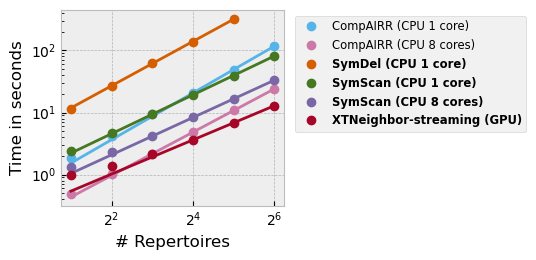

In [21]:
fig, ax = plt.subplots(figsize=(5.2, 2.4))
d = 1
for index, algorithm in enumerate(algorithms):
    data = df[(df['distance']==d) & (df['algorithm']==algorithm)]
    mean = data.groupby('n_repertoire').mean(numeric_only=True)
    x, y = mean.index, mean['runtime']

    slope, intercept, r, p, se = scipy.stats.linregress(np.log(x[-3:]), np.log(y[-3:]))
    print(algorithm, d, f'{slope:.3}, {se:.1}, {mean}')
    l, = ax.plot(x, y, 'o',
            label=algorithm_labels[algorithm],
            color=f'C{6-index}')
    ax.plot(x, np.exp(slope*np.log(x)+intercept), '-', color=l.get_color())
ax.set_yscale('log')
ax.set_xscale('log', base=2)
ax.set_xlabel('# Repertoires')
ax.set_ylabel('Time in seconds')
legend = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
legend_texts = legend.get_texts()
for i in range(1, 5):
    legend_texts[-i].set_weight('bold') 
fig.tight_layout(pad=0.0)
# fig.savefig('compairr_benchmark_.pdf')